In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from glob import glob   # To open files

# Size plots & labels
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 14

# Data Acquisition

In [2]:
from pydaqmx_helper.adc import ADC

myADC = ADC()
myADC.addChannels([0])

Activated Channel 0


In [17]:
V = np.zeros(525)
V_err = np.zeros(525)
for i in range(525):
    data = myADC.sampleVoltages(100, 5000)[0]
    V[i] = np.mean(data)
    V_err[i] = np.std(data)/np.sqrt(100)

In [ ]:
V = np.zeros(3125)
V_err = np.zeros(3125)
for i in range(3125):
    data = myADC.sampleVoltages(100, 5000)[0]
    V[i] = np.mean(data)
    V_err[i] = np.std(data)/np.sqrt(100)

<ErrorbarContainer object of 3 artists>

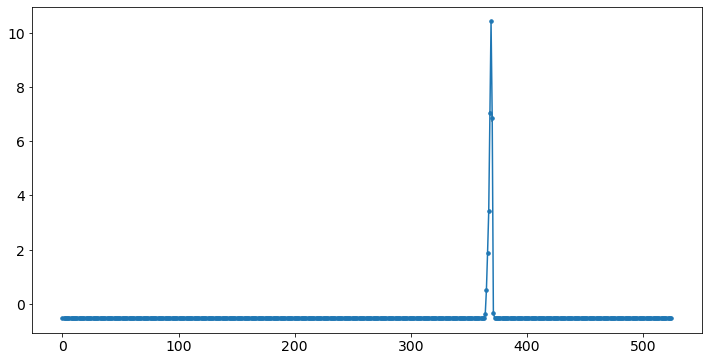

In [18]:
iterations = np.arange(525)
plt.errorbar(iterations, V, yerr=V_err, ecolor='grey', marker='o', ms=3.5)
#plt.xlim(2900,3125)

In [34]:
#np.savetxt('Downloads/Hg_650_400_5.csv', np.column_stack((V, V_err)), header='V, V_err')

# Calibration

In [2]:
# Import calibration data
V_laser, V_laser_err = np.loadtxt('Data/_laser_650_400.csv', unpack=True, delimiter=' ', skiprows=1)
V_Hg, V_Hg_err = np.loadtxt('Data/_Hg_650_400_0.csv', unpack=True, delimiter=' ', skiprows=1)
V_Na, V_Na_err = np.loadtxt('Data/_Na_650_400_0.csv', unpack=True, delimiter=' ', skiprows=1)

# Find peaks & their properties
laser_peaks, laser_props = find_peaks(V_laser, height=0)
Hg_peaks, Hg_props = find_peaks(V_Hg, height=0)
Na_peaks, Na_props = find_peaks(V_Na, height=0)

# Create dataset
dataset = [
    {"source": "Laser", "V": V_laser, "V_err": V_laser_err, "wl_th": [632.816], "peaks": laser_peaks, "peak_heights": laser_props["peak_heights"]},
    {"source": "Hg", "V": V_Hg, "V_err": V_Hg_err, "wl_th": [546.0735, 435.8328], "peaks": Hg_peaks, "peak_heights": Hg_props["peak_heights"]},
    {"source": "Na", "V": V_Na, "V_err": V_Na_err, "wl_th": [588.9950], "peaks": Na_peaks, "peak_heights": Na_props["peak_heights"]}
]


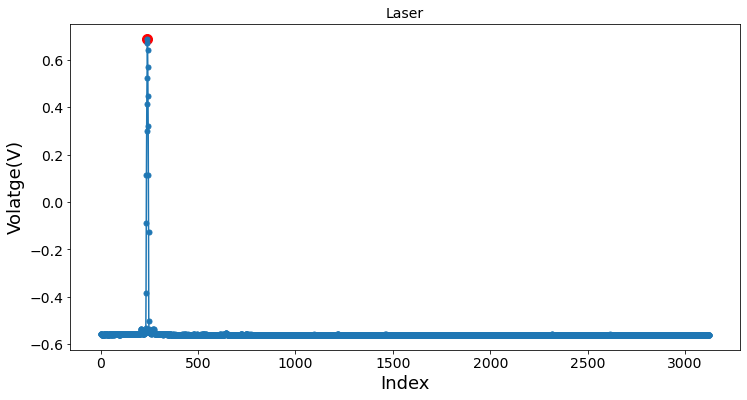

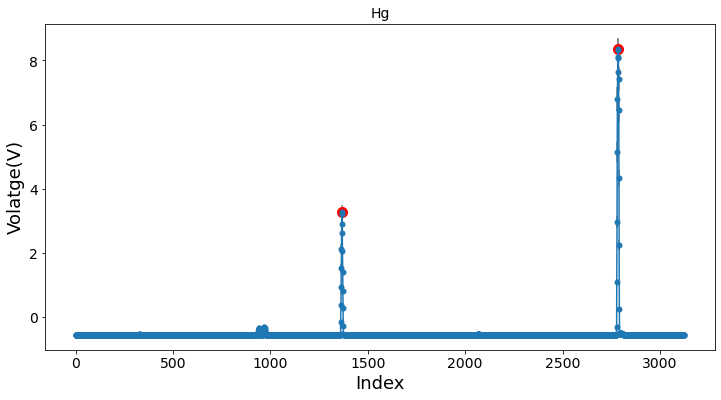

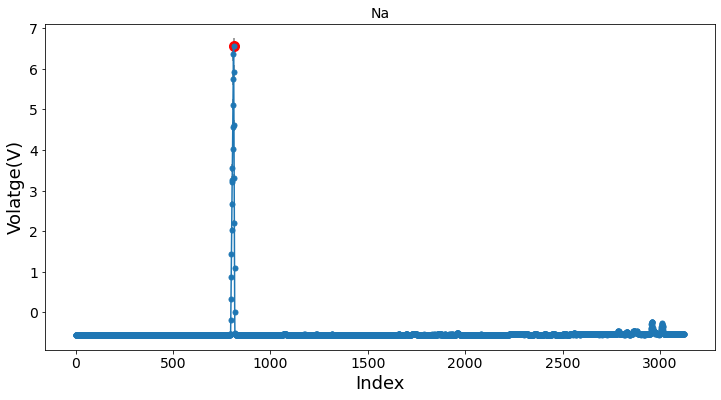

In [41]:
# Plot spectra of all sources
iterations = np.arange(len(V_laser))
for ds in dataset:
    plt.errorbar(iterations, ds['V'], yerr=abs(ds['V_err']), ecolor='grey', marker='o', ms=5)
    plt.scatter(ds['peaks'], ds['peak_heights'], color='r', marker='o', s=100, zorder=2)
    #plt.xlim(900,1000)
    #plt.ylim(-0.6, -0.3)
    plt.xlabel('Index')
    plt.ylabel('Volatge(V)')
    plt.title(ds['source'])
    plt.show()

Best-fit line: -0.0775x + 651.6849
Uncertainties on: m = 0.0002, c = 0.2758


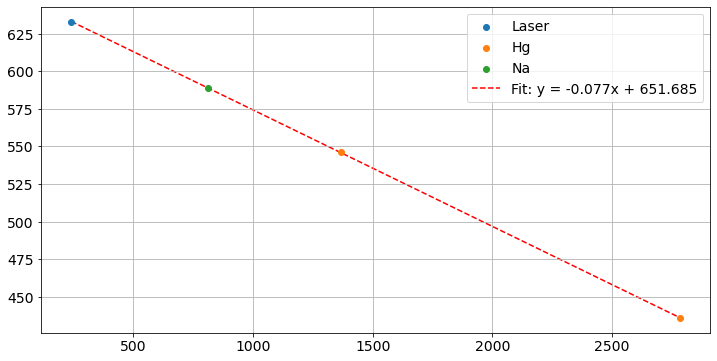

In [42]:
# Define function of a straight line for best-fit-line of calibration
def f(x,m,c):
    return m*x + c

# Initialize variables to store data points of peaks
peakses, wl_ths = [], []

# Store and plot the data points
for ds in dataset:
    peakses.extend(ds['peaks'])
    wl_ths.extend(ds['wl_th'])
    
    plt.scatter(ds['peaks'], ds['wl_th'], label=ds['source'])

# Obtain values for best fit
popt, pcov = curve_fit(f, peakses, wl_ths)
m, c = popt
m_err, c_err = np.sqrt(np.diag(pcov))

# Print them for a visual check
print(f"Best-fit line: {m:.4f}x + {c:.4f}")
print(f"Uncertainties on: m = {m_err:.4f}, c = {c_err:.4f}")

# Plot the line
xfit = np.linspace(min(peakses), max(peakses), 5000)
yfit = f(xfit, m, c)
plt.plot(xfit, yfit, 'r--', label=f"Fit: y = {m:.3f}x + {c:.3f}", zorder=0)

plt.legend()
plt.grid()
plt.show()

# Calibration (multimeasurements)

In [3]:
def get_peak_pos(paths, plot=True):
    file_list = glob(paths)
    peaks_pos = []
    for file in file_list:
        V, V_err = np.loadtxt(file, unpack=True, delimiter=' ', skiprows=1)
        pos, props = find_peaks(V, height=0)
        peaks_pos.append(pos)
        if plot==True:
            iterations = np.arange(len(V))
            plt.errorbar(iterations, V, yerr=abs(V_err), marker='o', ms=3.5, ecolor='grey')
            plt.scatter(pos, props['peak_heights'], color='red', s=80, zorder=1)
            #plt.xlim(2600, 2660)
            plt.show()
    return np.mean(peaks_pos, axis=0), np.std(peaks_pos, axis=0)

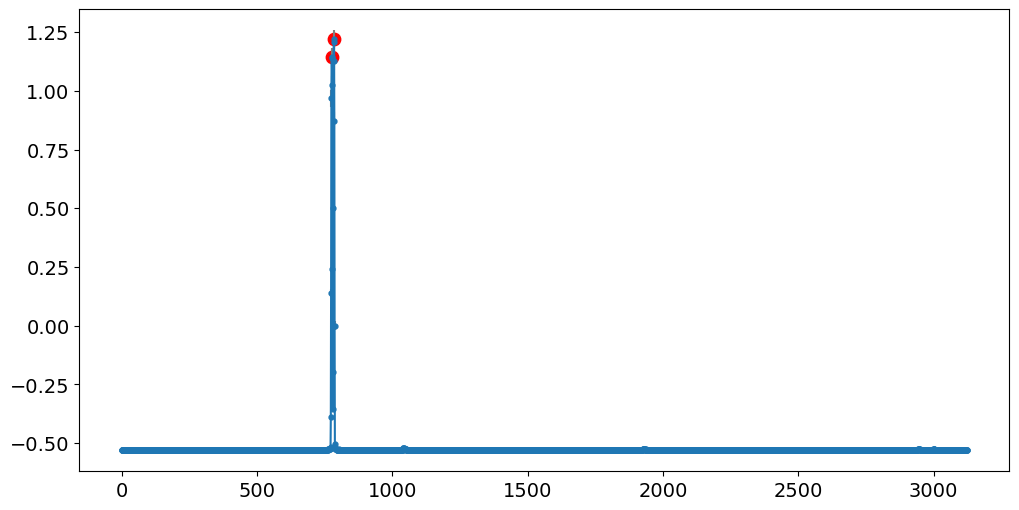

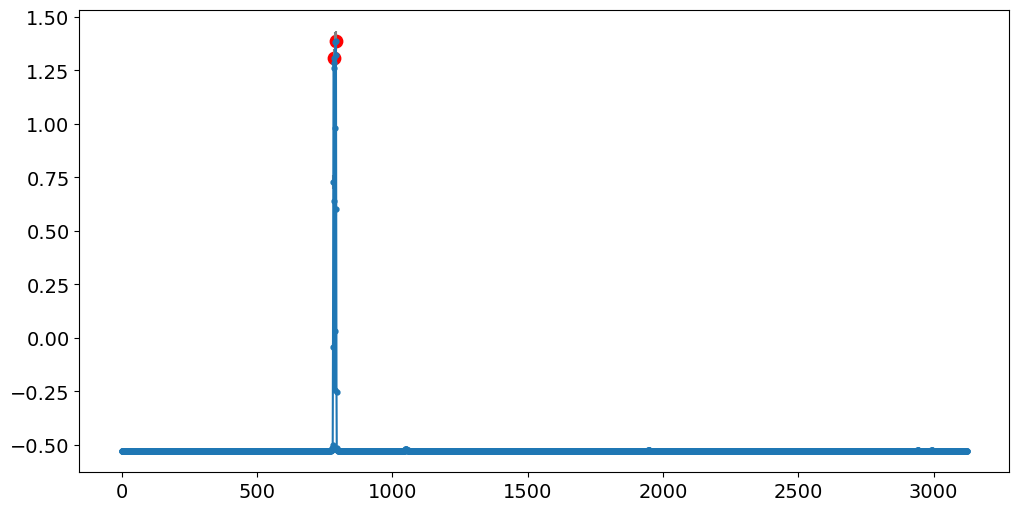

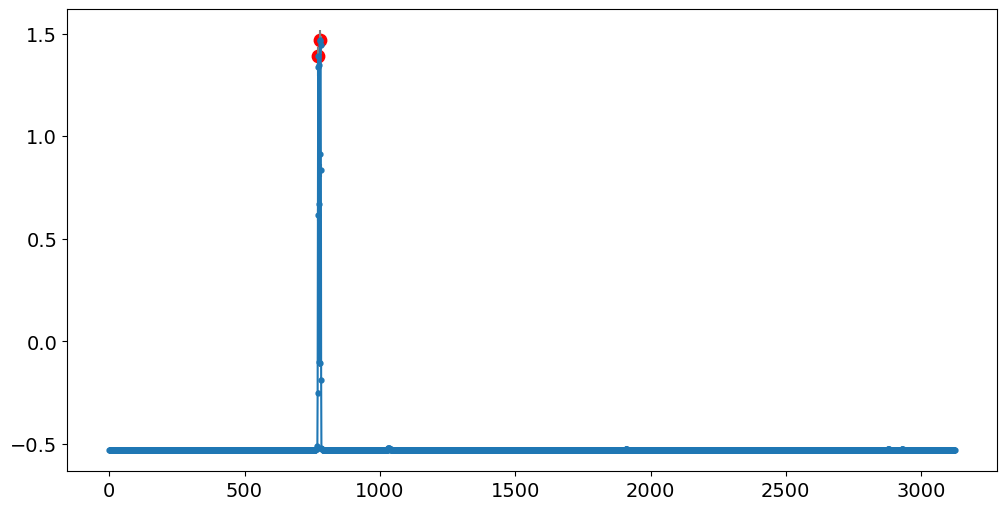

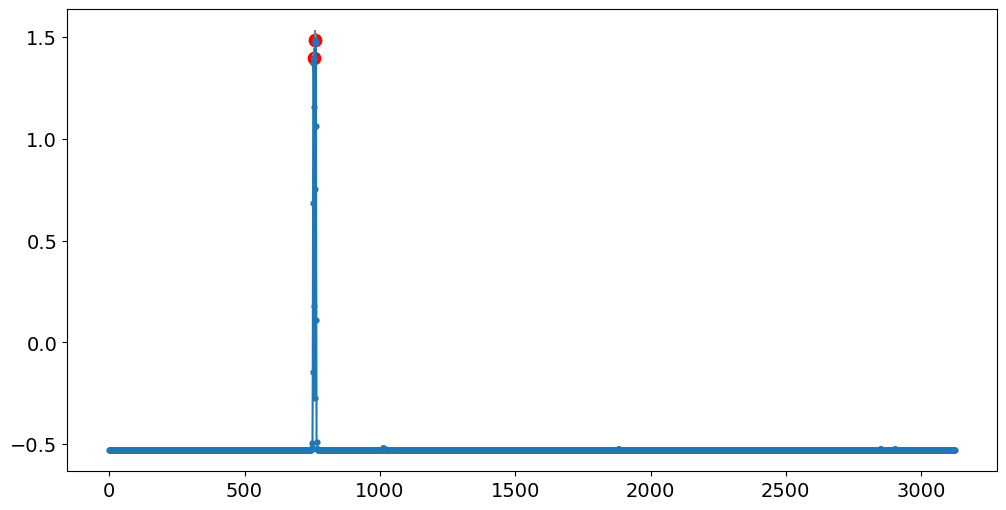

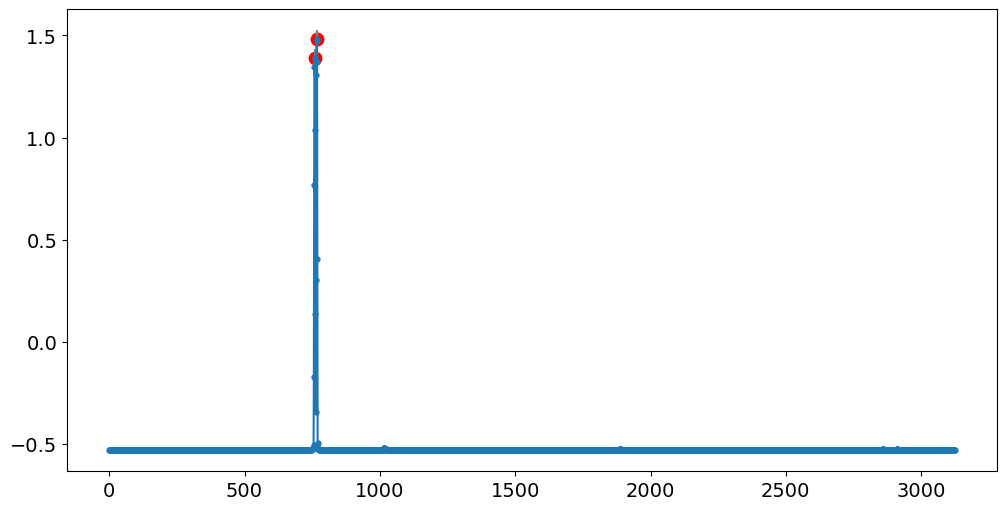

In [4]:
# Import calibration data
laser_paths = "Data/laser*.csv"
Hg_paths = "Data/Hg*.csv"
Na_paths = "Data/Na*.csv"

#laser_pos, laser_pos_err = get_peak_pos(laser_files)
#Hg_pos, Hg_pos_err = get_peak_pos(Hg_paths)
Na_pos, Na_pos_err = get_peak_pos(Na_paths)

# Create dataset
dataset = {
    #"Laser": {"peaks": laser_pos, "peaks_err": laser_pos_err, "wl_th": [632.816]},
    #"Hg": {"peaks": Hg_pos, "peaks_err": Hg_pos_err, "wl_th": [546.0735, 435.8328]},
    "Na": {"peaks": Na_pos, "peaks_err": Na_pos_err, "wl_th": [588.9950]}
}

In [5]:
dataset = {
    "Laser": {"peaks": laser_peaks, "peaks_err": [0], "wl_th": [632.816]},
    "Hg": {"peaks": Hg_peaks, "peaks_err": [0,0], "wl_th": [546.0735, 435.8328]},
    "Na": {"peaks": Na_pos, "peaks_err": Na_pos_err, "wl_th": [589.5924, 588.9950]}
}

C:\Users\user\anaconda3-64bit\Lib\site-packages\scipy\optimize\_minpack_py.py:968: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma


RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 600.

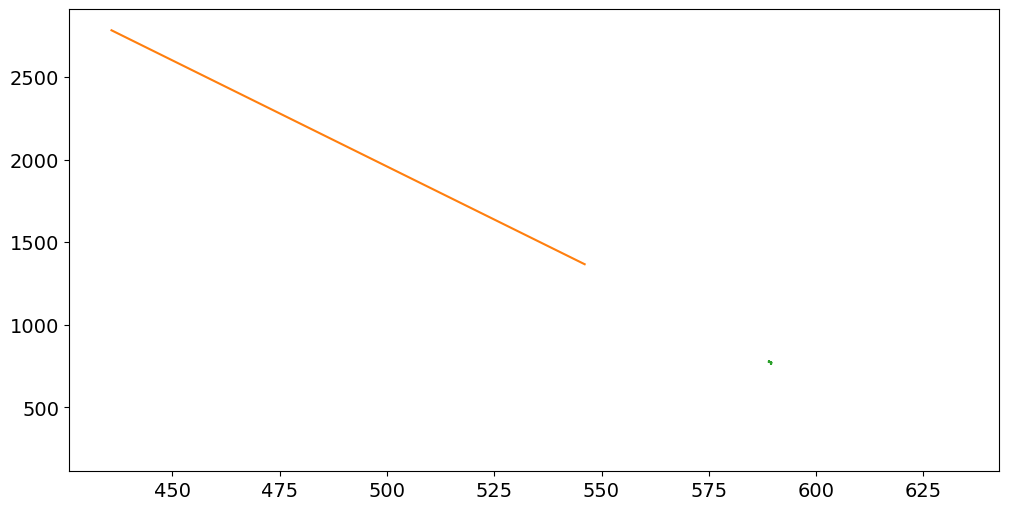

In [6]:
# Define function of a straight line for best-fit-line of calibration
def f(x,m,c):
    return m*x + c

# Initialize variables to store data points of peaks
peakses, peakses_err, wl_ths = [], [], []

# Store and plot the data points
for ds in dataset:
    peakses.extend(dataset[ds]['peaks'])
    peakses_err.extend(dataset[ds]['peaks_err'])
    wl_ths.extend(dataset[ds]['wl_th'])
    
    plt.errorbar(dataset[ds]['wl_th'], dataset[ds]['peaks'], yerr=dataset[ds]['peaks_err'], label=ds)

# Obtain values for best fit
popt, pcov = curve_fit(f, wl_ths, peakses, sigma=peakses_err, absolute_sigma=True)
m, c = popt
m_err, c_err = np.sqrt(np.diag(pcov))

# Print them for a visual check
print(f"Best-fit line: {m:.4f}x + {c:.4f}")
print(f"Uncertainties on: m = {m_err:.4f}, c = {c_err:.4f}")

# Plot the line
xfit = np.linspace(min(wl_ths), max(wl_ths), 500)
yfit = f(xfit, m, c)
plt.plot(xfit, yfit, 'r--', label=f"Fit: y = {m:.3f}x + {c:.3f}", zorder=0)

plt.legend()
plt.grid()
plt.show()

# Data Anlaysis

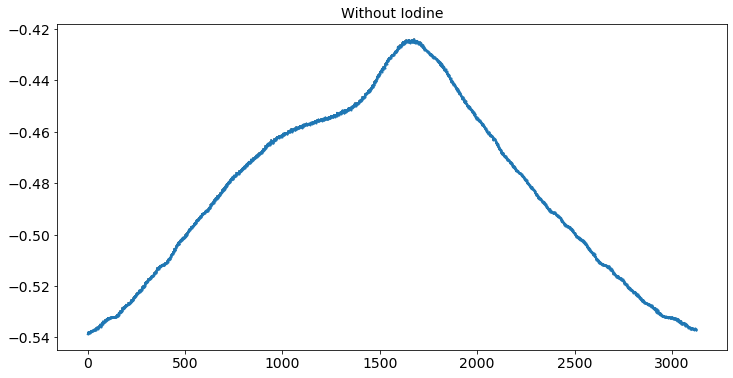

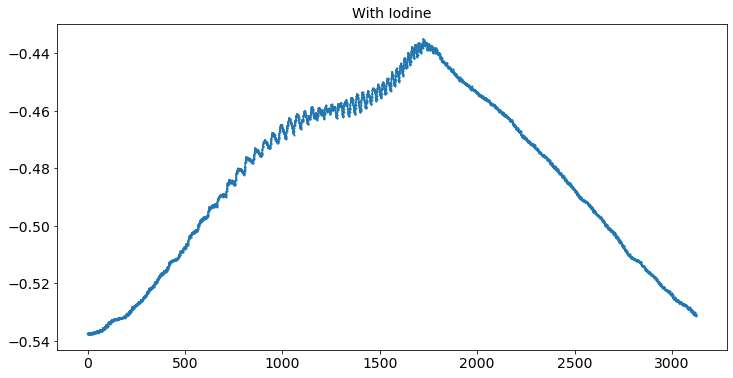

In [57]:
iterations = np.arange(len(V_laser))

V, V_err = np.loadtxt('Downloads/tungsen_wo_trial_400_650_0.csv', unpack=True, delimiter=' ', skiprows=1)
plt.errorbar(iterations, V[::-1], yerr=V_err[::-1], ecolor='grey', marker='o', ms=1)
plt.title('Without Iodine')
plt.show()

V, V_err = np.loadtxt('Downloads/tungsen_w_trial_650_400_0.csv', unpack=True, delimiter=' ', skiprows=1)
plt.errorbar(iterations, V, yerr=V_err, ecolor='grey', marker='o', ms=1)
plt.title('With Iodine')
plt.show()